# 04. Model Evaluation on Unseen Test Set

## Overview
In this notebook, we evaluate our trained machine learning pipelines on the unseen IBM Telco holdout test set (`X_test.csv`, `y_test.csv`).

### Evaluation Strategy:
1. **Comprehensive Performance Metrics**: Precision, Recall, F1-Score, ROC-AUC, PR-AUC (Average Precision), and Brier Score.
2. **Comparative Visualizations**: ROC Curves and Precision-Recall Curves overlaying all model candidates.
3. **Decision Threshold Tuning**: Optimize the classification threshold on training out-of-fold predictions to balance Precision and Recall for retention teams.
4. **Confusion Matrix Analysis**: Detailed breakdown of True Positives (caught churners) and False Positives (unnecessary retention costs).
5. **Probability Calibration**: Assess whether model predicted probabilities accurately reflect actual churn risk.


### Library Imports and Setup
We import evaluation metrics from scikit-learn, visualization libraries, and path configuration.

In [1]:
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.calibration import calibration_curve

# Set project root path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("Evaluation setup complete.")


Evaluation setup complete.


### Load Test Set and Trained Model Pipelines
We load `X_test.csv`, `y_test.csv`, `X_train.csv`, `y_train.csv`, and fitted pipelines from `models/models.joblib`.

In [2]:
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns").astype(int)
X_test = pd.read_csv(DATA_DIR / "X_test.csv")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns").astype(int)

models_dict = joblib.load(MODEL_DIR / "models.joblib")
with open(MODEL_DIR / "best_candidate_metadata.json", "r") as f:
    best_metadata = json.load(f)

best_candidate_name = best_metadata['candidate_name']

print(f"Loaded Test Set: {X_test.shape[0]} rows | Positive Churn Rate: {y_test.mean():.2%}")
print(f"Candidate Models Loaded: {list(models_dict.keys())}")
print(f"Selected Best Model: {best_candidate_name}")


Loaded Test Set: 1409 rows | Positive Churn Rate: 26.54%
Candidate Models Loaded: ['LogisticRegression__none', 'LogisticRegression__class_weight', 'LogisticRegression__smote', 'RandomForest__none', 'RandomForest__class_weight', 'RandomForest__smote', 'XGBoost__none', 'XGBoost__class_weight', 'XGBoost__smote']
Selected Best Model: LogisticRegression__none


### Operational Decision Threshold Optimization
Standard 0.50 decision thresholds are sub-optimal for imbalanced retention settings. Here, we perform 5-fold cross-validation on the training set to obtain Out-Of-Fold (OOF) predicted probabilities, and locate the threshold that maximizes F1-Score.

In [3]:
best_pipeline = models_dict[best_candidate_name]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Obtain out-of-fold predicted probabilities on training set
oof_probs = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

# Compute Precision-Recall curve across candidate thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)

# Find optimal threshold maximizing F1
best_idx = np.argmax(f1_scores[:-1])
optimal_threshold = float(thresholds[best_idx])

print(f"Optimal Decision Threshold (OOF F1 Maximization): {optimal_threshold:.4f}")
print(f"OOF F1-Score at Optimal Threshold: {f1_scores[best_idx]:.4f}")

# Save threshold metadata
threshold_info = {
    'threshold': optimal_threshold,
    'selection_method': 'training_out_of_fold_f1_maximization',
    'oof_f1_score': float(f1_scores[best_idx])
}
with open(MODEL_DIR / "decision_threshold.json", "w") as f:
    json.dump(threshold_info, f, indent=2)

# Save best model bundle for SHAP / external validation
joblib.dump({
    'name': best_candidate_name,
    'model': best_pipeline,
    'threshold': optimal_threshold
}, MODEL_DIR / "best_model.joblib")


Optimal Decision Threshold (OOF F1 Maximization): 0.3005
OOF F1-Score at Optimal Threshold: 0.6533


['C:\\Sriram Churn\\models\\best_model.joblib']

### Cost-Sensitive Decision Threshold Optimization
Under standard industry assumptions, customer acquisition costs typically exceed retention costs by a factor of 5 to 7. To reflect this asymmetric risk profile, we establish explicit business cost parameters (COST_FALSE_NEGATIVE = 5.0, COST_FALSE_POSITIVE = 1.0) and locate the decision threshold that minimizes total expected operational loss on out-of-fold cross-validation predictions.

In [4]:
COST_FALSE_NEGATIVE = 5.0
COST_FALSE_POSITIVE = 1.0

# Sweep thresholds on out-of-fold training probabilities
costs = []
for t in thresholds:
    preds_t = (oof_probs >= t).astype(int)
    fn = np.sum((y_train == 1) & (preds_t == 0))
    fp = np.sum((y_train == 0) & (preds_t == 1))
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    costs.append(total_cost)

cost_idx = np.argmin(costs)
cost_optimal_threshold = float(thresholds[cost_idx])

# Update decision threshold json without overwriting existing keys
with open(MODEL_DIR / "decision_threshold.json", "r") as f:
    thresh_data = json.load(f)

thresh_data['cost_optimal_threshold'] = cost_optimal_threshold
thresh_data['cost_false_negative_weight'] = COST_FALSE_NEGATIVE
thresh_data['cost_false_positive_weight'] = COST_FALSE_POSITIVE

with open(MODEL_DIR / "decision_threshold.json", "w") as f:
    json.dump(thresh_data, f, indent=2)

# Evaluate both thresholds on test set
best_test_probs = best_pipeline.predict_proba(X_test)[:, 1]

preds_f1 = (best_test_probs >= optimal_threshold).astype(int)
preds_cost = (best_test_probs >= cost_optimal_threshold).astype(int)

cm_f1 = confusion_matrix(y_test, preds_f1)
cm_cost = confusion_matrix(y_test, preds_cost)

cost_f1 = (cm_f1[1, 0] * COST_FALSE_NEGATIVE) + (cm_f1[0, 1] * COST_FALSE_POSITIVE)
cost_cost = (cm_cost[1, 0] * COST_FALSE_NEGATIVE) + (cm_cost[0, 1] * COST_FALSE_POSITIVE)

threshold_comparison_df = pd.DataFrame([
    {
        'threshold_type': 'F1-Optimal',
        'threshold': round(optimal_threshold, 4),
        'TN': cm_f1[0, 0], 'FP': cm_f1[0, 1], 'FN': cm_f1[1, 0], 'TP': cm_f1[1, 1],
        'precision': round(precision_score(y_test, preds_f1, zero_division=0), 4),
        'recall': round(recall_score(y_test, preds_f1, zero_division=0), 4),
        'f1_score': round(f1_score(y_test, preds_f1, zero_division=0), 4),
        'expected_cost': cost_f1
    },
    {
        'threshold_type': 'Cost-Optimal',
        'threshold': round(cost_optimal_threshold, 4),
        'TN': cm_cost[0, 0], 'FP': cm_cost[0, 1], 'FN': cm_cost[1, 0], 'TP': cm_cost[1, 1],
        'precision': round(precision_score(y_test, preds_cost, zero_division=0), 4),
        'recall': round(recall_score(y_test, preds_cost, zero_division=0), 4),
        'f1_score': round(f1_score(y_test, preds_cost, zero_division=0), 4),
        'expected_cost': cost_cost
    }
])

print(f"Cost-Optimal Decision Threshold: {cost_optimal_threshold:.4f}")
print("=== Threshold Strategy Comparison on Holdout Test Set ===")
display(threshold_comparison_df)

Cost-Optimal Decision Threshold: 0.1449
=== Threshold Strategy Comparison on Holdout Test Set ===


,threshold_type,threshold,TN,FP,FN,TP,precision,recall,f1_score,expected_cost
0,F1-Optimal,0.3005,799,236,97,277,0.5400,0.7406,0.6246,721.0
1,Cost-Optimal,0.1449,623,412,32,342,0.4536,0.9144,0.6064,572.0


### Evaluate Models on Unseen Test Set
We compute classification metrics on the holdout test set for all model candidates using both standard (0.50) and optimal decision thresholds.

In [5]:
results_rows = []

for candidate_name, pipeline in models_dict.items():
    probs = pipeline.predict_proba(X_test)[:, 1]
    
    # Standard threshold 0.50 predictions
    preds_50 = (probs >= 0.50).astype(int)
    
    # Optimal threshold predictions for the selected model, 0.50 for others
    thresh = optimal_threshold if candidate_name == best_candidate_name else 0.50
    preds_opt = (probs >= thresh).astype(int)
    
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    brier = brier_score_loss(y_test, probs)
    
    results_rows.append({
        'candidate': candidate_name,
        'model': candidate_name.split('__')[0],
        'strategy': candidate_name.split('__')[1],
        'threshold_used': round(thresh, 4),
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'precision': precision_score(y_test, preds_opt, zero_division=0),
        'recall': recall_score(y_test, preds_opt, zero_division=0),
        'f1_score': f1_score(y_test, preds_opt, zero_division=0),
        'brier_score': brier
    })

test_results_df = pd.DataFrame(results_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
print("Unseen Test Set Model Evaluation Summary")
display(test_results_df)

test_results_df.to_csv(TABLES_DIR / "model_comparison_test.csv", index=False)
test_results_df.to_csv(TABLES_DIR / "test_metrics.csv", index=False)


Unseen Test Set Model Evaluation Summary


,candidate,model,strategy,threshold_used,roc_auc,pr_auc,precision,recall,f1_score,brier_score
0,XGBoost__class_weight,XGBoost,class_weight,0.5000,0.853519,0.665145,0.530864,0.804813,0.639745,0.155091
1,LogisticRegression__class_weight,LogisticRegression,class_weight,0.5000,0.853068,0.670466,0.525271,0.778075,0.627155,0.160113
2,LogisticRegression__none,LogisticRegression,none,0.3005,0.852913,0.671035,0.539961,0.740642,0.624577,0.133384
3,RandomForest__none,RandomForest,none,0.5000,0.852227,0.667016,0.667785,0.532086,0.592262,0.132872
4,LogisticRegression__smote,LogisticRegression,smote,0.5000,0.851595,0.669349,0.523636,0.770053,0.623377,0.159527
5,RandomForest__class_weight,RandomForest,class_weight,0.5000,0.851473,0.666299,0.554435,0.735294,0.632184,0.147325
6,RandomForest__smote,RandomForest,smote,0.5000,0.850775,0.658889,0.573913,0.705882,0.633094,0.146394
7,XGBoost__none,XGBoost,none,0.5000,0.849482,0.654881,0.665552,0.532086,0.591382,0.135012
8,XGBoost__smote,XGBoost,smote,0.5000,0.848703,0.658985,0.568889,0.684492,0.621359,0.144899


### Imbalance Strategy Trade-Off Summary
We aggregate performance metrics across all model architectures to evaluate the net recall gained and precision lost by imbalance mitigation strategies relative to the unweighted baseline.

In [6]:
base_rec = test_results_df[test_results_df['strategy'] == 'none']['recall'].mean()
base_prec = test_results_df[test_results_df['strategy'] == 'none']['precision'].mean()

tradeoff_rows = []
for strat in ['none', 'class_weight', 'smote']:
    strat_sub = test_results_df[test_results_df['strategy'] == strat]
    m_rec = strat_sub['recall'].mean()
    m_prec = strat_sub['precision'].mean()
    m_f1 = strat_sub['f1_score'].mean()
    rec_gained = m_rec - base_rec
    prec_lost = base_prec - m_prec
    tradeoff_rows.append({
        'strategy': strat,
        'mean_precision': round(m_prec, 4),
        'mean_recall': round(m_rec, 4),
        'mean_f1': round(m_f1, 4),
        'mean_recall_gained': round(rec_gained, 4),
        'mean_precision_lost': round(prec_lost, 4)
    })

strategy_tradeoff_df = pd.DataFrame(tradeoff_rows)
print("=== Imbalance Strategy Trade-Off Summary ===")
display(strategy_tradeoff_df)

best_strat_row = strategy_tradeoff_df.sort_values('mean_f1', ascending=False).iloc[0]
print(f"Strategy '{best_strat_row['strategy']}' provides the optimal trade-off with mean F1 of {best_strat_row['mean_f1']:.4f}, gaining {best_strat_row['mean_recall_gained']:+.4f} recall while losing {best_strat_row['mean_precision_lost']:+.4f} precision relative to baseline.")

=== Imbalance Strategy Trade-Off Summary ===


,strategy,mean_precision,mean_recall,mean_f1,mean_recall_gained,mean_precision_lost
0,none,0.6244,0.6016,0.6027,0.0000,0.0000
1,class_weight,0.5369,0.7727,0.6330,0.1711,0.0876
2,smote,0.5555,0.7201,0.6259,0.1185,0.0690


Strategy 'class_weight' provides the optimal trade-off with mean F1 of 0.6330, gaining +0.1711 recall while losing +0.0876 precision relative to baseline.


### Comparative ROC and Precision-Recall Curves
We plot the ROC curves and Precision-Recall curves on the unseen test set.

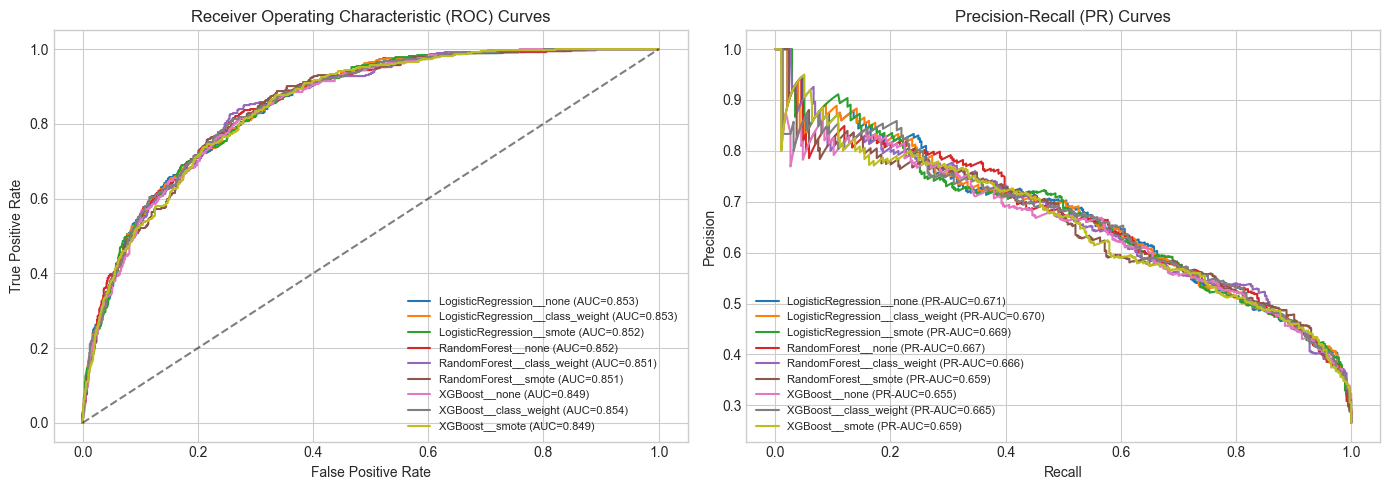

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for candidate_name, pipeline in models_dict.items():
    probs = pipeline.predict_proba(X_test)[:, 1]
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{candidate_name} (AUC={auc_val:.3f})")
    
    # PR Curve
    prec, rec, _ = precision_recall_curve(y_test, probs)
    pr_auc_val = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, label=f"{candidate_name} (PR-AUC={pr_auc_val:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("Receiver Operating Characteristic (ROC) Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8, loc='lower right')

axes[1].set_title("Precision-Recall (PR) Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_pr_curves_comparison.png", dpi=150)
plt.savefig(FIGURES_DIR / "roc_curves.png", dpi=150)
plt.show()


### Threshold Sensitivity Curve
We examine how changing the decision threshold from 0.10 to 0.90 impacts Precision, Recall, and F1-Score for the best model.

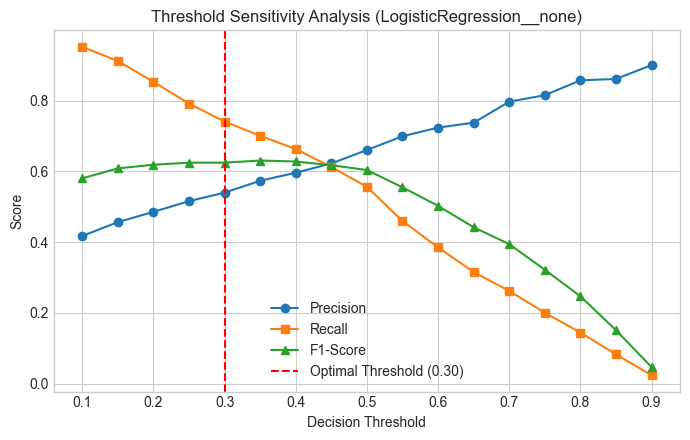

In [8]:
best_probs = best_pipeline.predict_proba(X_test)[:, 1]

threshold_sweep = np.arange(0.10, 0.95, 0.05)
sweep_rows = []

for t in threshold_sweep:
    preds = (best_probs >= t).astype(int)
    sweep_rows.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds, zero_division=0),
        'f1': f1_score(y_test, preds, zero_division=0)
    })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(TABLES_DIR / "threshold_sensitivity.csv", index=False)

plt.figure(figsize=(7, 4.5))
plt.plot(sweep_df['threshold'], sweep_df['precision'], marker='o', label='Precision', color='steelblue')
plt.plot(sweep_df['threshold'], sweep_df['recall'], marker='s', label='Recall', color='darkorange')
plt.plot(sweep_df['threshold'], sweep_df['f1'], marker='^', label='F1-Score', color='forestgreen')

plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.title(f"Threshold Sensitivity Analysis ({best_candidate_name})")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_sensitivity.png", dpi=150)
plt.show()


### Confusion Matrix for Selected Best Model
We visualize the confusion matrix of the selected best model evaluated on the test set at the optimal threshold.

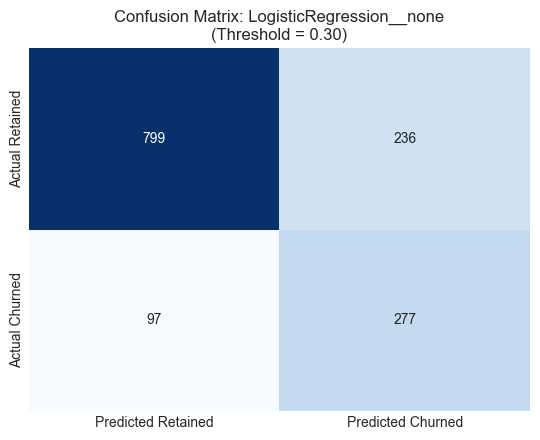

True Negatives:  799 (Retained correctly identified)
False Positives: 236 (Retained misclassified as churners)
False Negatives: 97 (Churners missed)
True Positives:  277 (Churners correctly identified)


In [9]:
best_test_preds = (best_probs >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, best_test_preds)

cm_df = pd.DataFrame(cm, index=['Actual Retained (0)', 'Actual Churned (1)'], columns=['Predicted Retained (0)', 'Predicted Churned (1)'])
cm_df.to_csv(TABLES_DIR / "confusion_matrix_final_model.csv")

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'])
plt.title(f"Confusion Matrix: {best_candidate_name}\n(Threshold = {optimal_threshold:.2f})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_final_model.png", dpi=150)
plt.show()

print(f"True Negatives:  {cm[0,0]} (Retained correctly identified)")
print(f"False Positives: {cm[0,1]} (Retained misclassified as churners)")
print(f"False Negatives: {cm[1,0]} (Churners missed)")
print(f"True Positives:  {cm[1,1]} (Churners correctly identified)")


### Reliability Calibration Curve
We evaluate whether predicted churn probabilities match true observed churn rates using a calibration reliability curve.

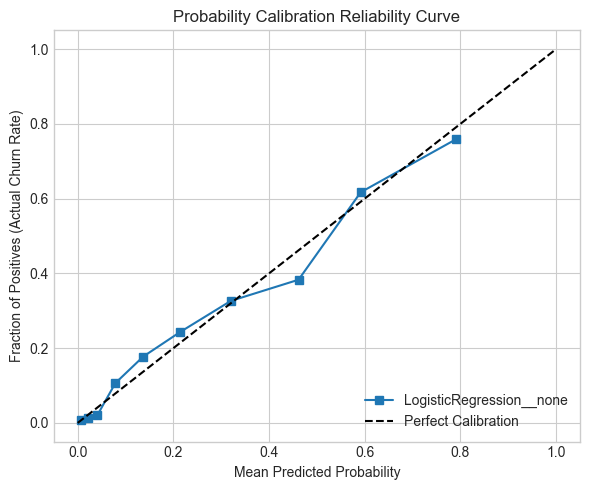

Evaluation completed successfully!


In [10]:
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, best_probs, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 5))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{best_candidate_name}")
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
plt.title("Probability Calibration Reliability Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives (Actual Churn Rate)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "calibration_plot.png", dpi=150)
plt.show()

print("Evaluation completed successfully!")
